# Prédiction du Turnover des Employés — Notebook 1
## Étape 1 (Setup) & Étape 2 (Analyse Exploratoire des Données — EDA)

**Projet Capstone M2 — Jebari Oussema**  
Dataset : IBM HR Analytics Employee Attrition (1 470 employés, 35 variables)

---

Ce notebook couvre :
1. L'installation et l'import des librairies
2. Le chargement du dataset
3. L'exploration générale (structure, types, valeurs manquantes)
4. L'analyse de la variable cible (Attrition)
5. Les visualisations clés (corrélations, facteurs de départ)

---
## ÉTAPE 1 — Setup de l'environnement

Si c'est la première fois, décommente et exécute la cellule ci-dessous pour installer les librairies. Sinon, passe directement aux imports.

In [7]:
# Installation des librairies (à exécuter une seule fois)
# !pip install pandas numpy matplotlib seaborn scikit-learn shap imbalanced-learn xgboost

In [8]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librairies importées avec succès !')

ModuleNotFoundError: No module named 'pandas'

---
## ÉTAPE 2 — Chargement et exploration des données (EDA)

### 2.1 Chargement du dataset

In [ ]:
# Chargement du fichier CSV
# Note : si le fichier n'est pas dans le même dossier, mets le chemin complet entre guillemets
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Aperçu des premières lignes
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### 2.2 Dimensions et structure générale

In [ ]:
# Nombre de lignes et de colonnes
print(f'Nombre d\'employés (lignes) : {df.shape[0]}')
print(f'Nombre de variables (colonnes) : {df.shape[1]}')

Nombre d'employés (lignes) : 1470
Nombre de variables (colonnes) : 35


In [ ]:
# Informations sur les types de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Statistiques descriptives des variables numériques
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 2.3 Vérification des valeurs manquantes

In [ ]:
# Total des valeurs manquantes
missing = df.isnull().sum().sum()
print(f'Total des valeurs manquantes dans le dataset : {missing}')

if missing == 0:
    print('Aucune valeur manquante — le dataset est complet.')
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total des valeurs manquantes dans le dataset : 0
Aucune valeur manquante — le dataset est complet.


### 2.4 Détection des colonnes inutiles (constantes)

Certaines colonnes ont la même valeur pour tous les employés : elles n'apportent aucune information au modèle et seront supprimées lors de la préparation des données.

In [ ]:
# Identification des colonnes constantes
colonnes_constantes = [col for col in df.columns if df[col].nunique() == 1]
print('Colonnes constantes (à supprimer) :', colonnes_constantes)

for col in colonnes_constantes:
    print(f'  - {col} : valeur unique = {df[col].unique()[0]}')

Colonnes constantes (à supprimer) : ['EmployeeCount', 'Over18', 'StandardHours']
  - EmployeeCount : valeur unique = 1
  - Over18 : valeur unique = Y
  - StandardHours : valeur unique = 80


### 2.5 Analyse de la variable cible : Attrition

C'est la variable que notre modèle cherchera à prédire. On observe sa distribution.

In [ ]:
# Distribution en nombre et en pourcentage
print('Répartition en effectifs :')
print(df['Attrition'].value_counts())
print('\nRépartition en pourcentage :')
print((df['Attrition'].value_counts(normalize=True) * 100).round(2))

Répartition en effectifs :
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Répartition en pourcentage :
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


C:\Users\jebar\AppData\Local\Temp\ipykernel_13232\3830001100.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])


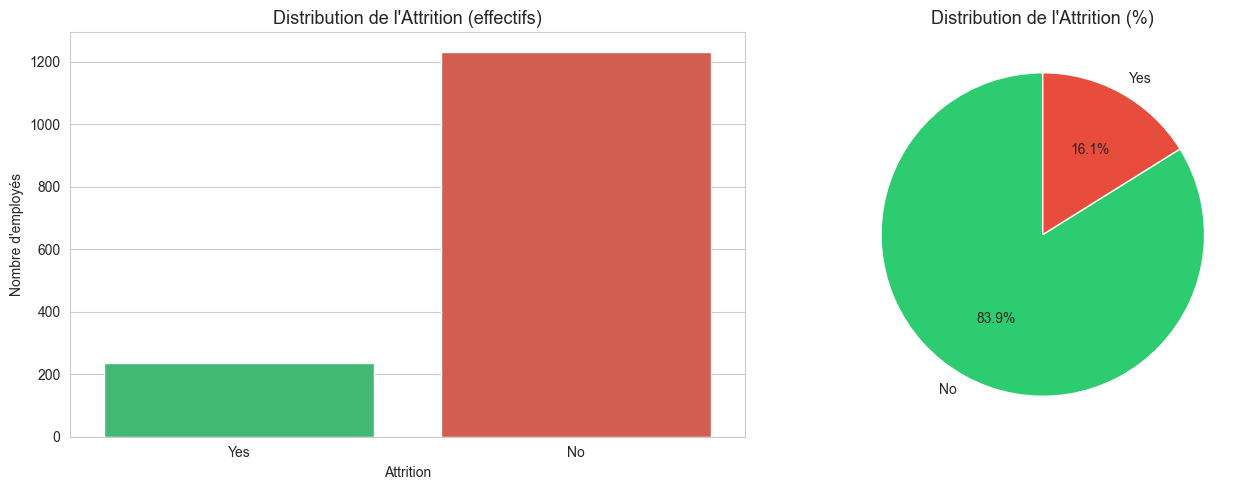

Observation : le dataset est déséquilibré (~16% de départs).
Ce déséquilibre devra être corrigé (SMOTE) avant la modélisation.


In [ ]:
# Visualisation de la distribution de l'attrition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
sns.countplot(x='Attrition', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution de l\'Attrition (effectifs)', fontsize=13)
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Nombre d\'employés')

# Graphique camembert
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1],
                                         colors=['#2ecc71', '#e74c3c'],
                                         startangle=90)
axes[1].set_title('Distribution de l\'Attrition (%)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('Observation : le dataset est déséquilibré (~16% de départs).')
print('Ce déséquilibre devra être corrigé (SMOTE) avant la modélisation.')

### 2.6 Matrice de corrélation des variables numériques

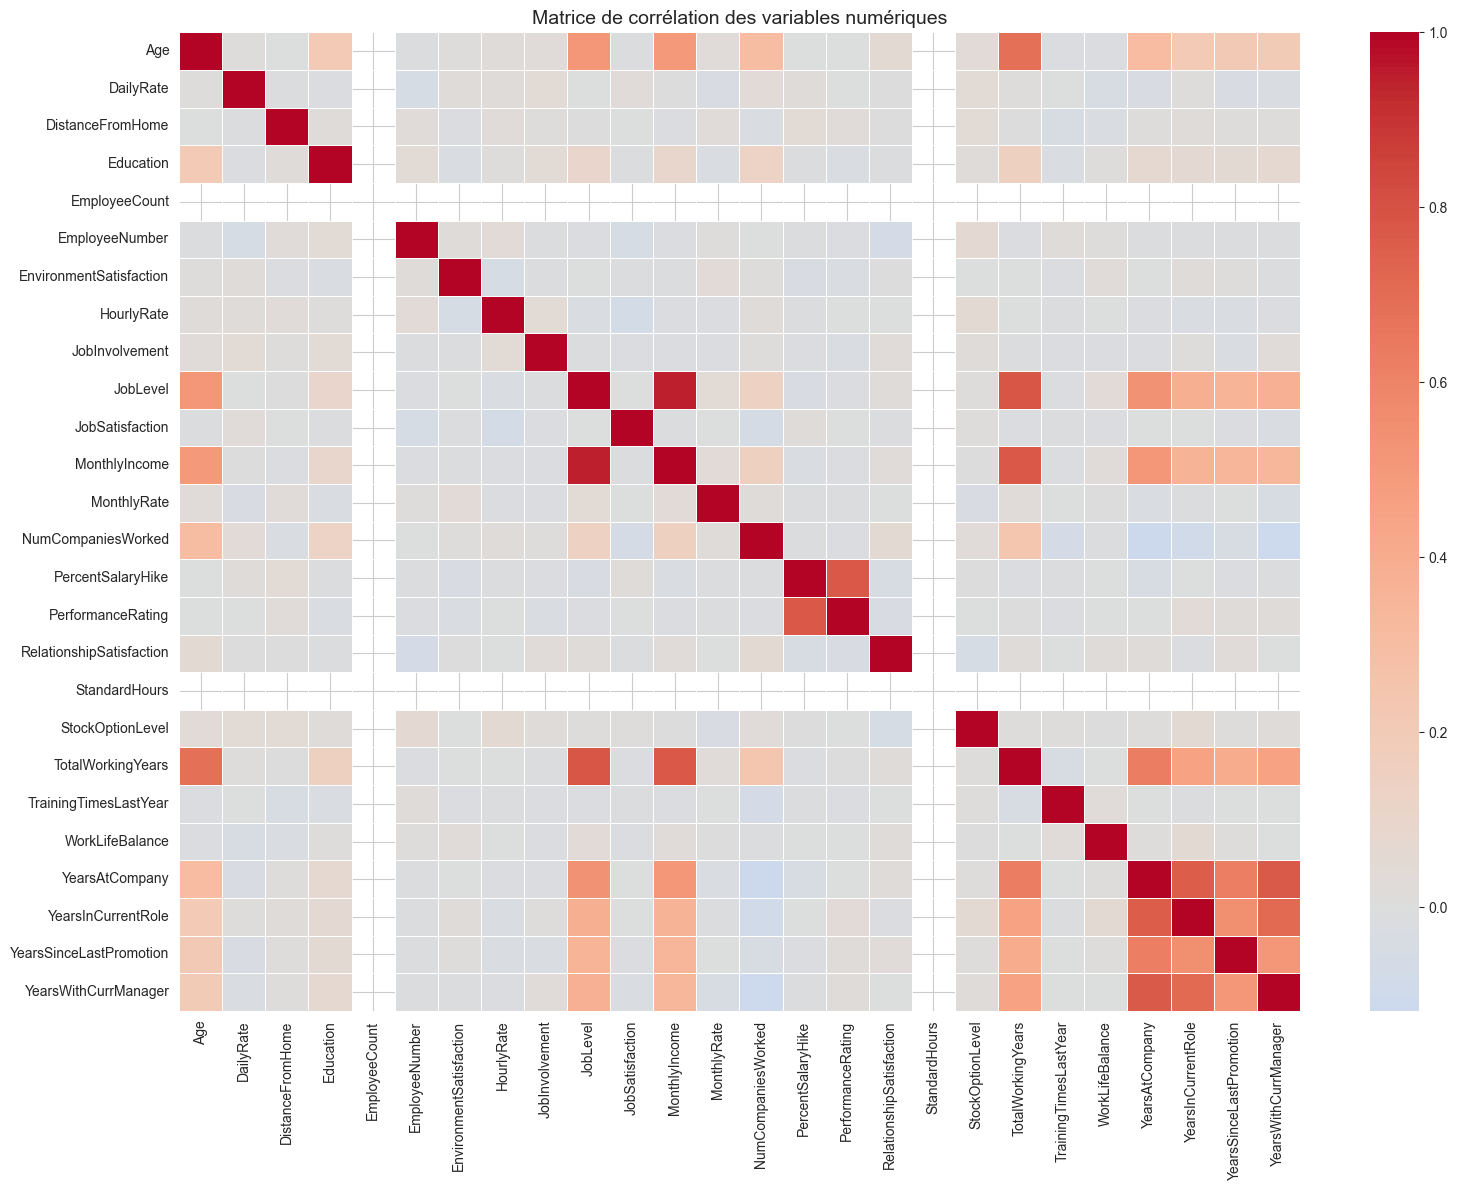

In [ ]:
# Matrice de corrélation
plt.figure(figsize=(16, 12))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

### 2.7 Analyse des facteurs clés de départ

On examine quelques variables identifiées dans la revue de littérature comme déterminantes du turnover.

C:\Users\jebar\AppData\Local\Temp\ipykernel_13232\3530188812.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='Age', data=df, ax=axes[1],


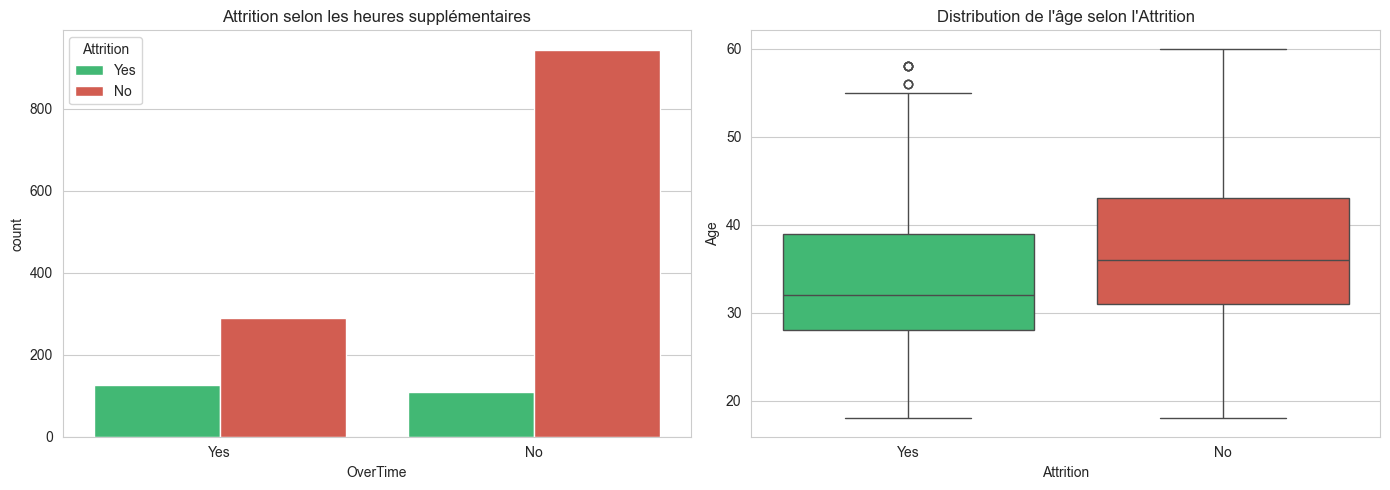

In [ ]:
# Attrition selon les heures supplémentaires (OverTime)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='OverTime', hue='Attrition', data=df, ax=axes[0],
              palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Attrition selon les heures supplémentaires')

# Attrition selon l'âge
sns.boxplot(x='Attrition', y='Age', data=df, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribution de l\'âge selon l\'Attrition')

plt.tight_layout()
plt.show()

C:\Users\jebar\AppData\Local\Temp\ipykernel_13232\2785156241.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[0],
C:\Users\jebar\AppData\Local\Temp\ipykernel_13232\2785156241.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[1],


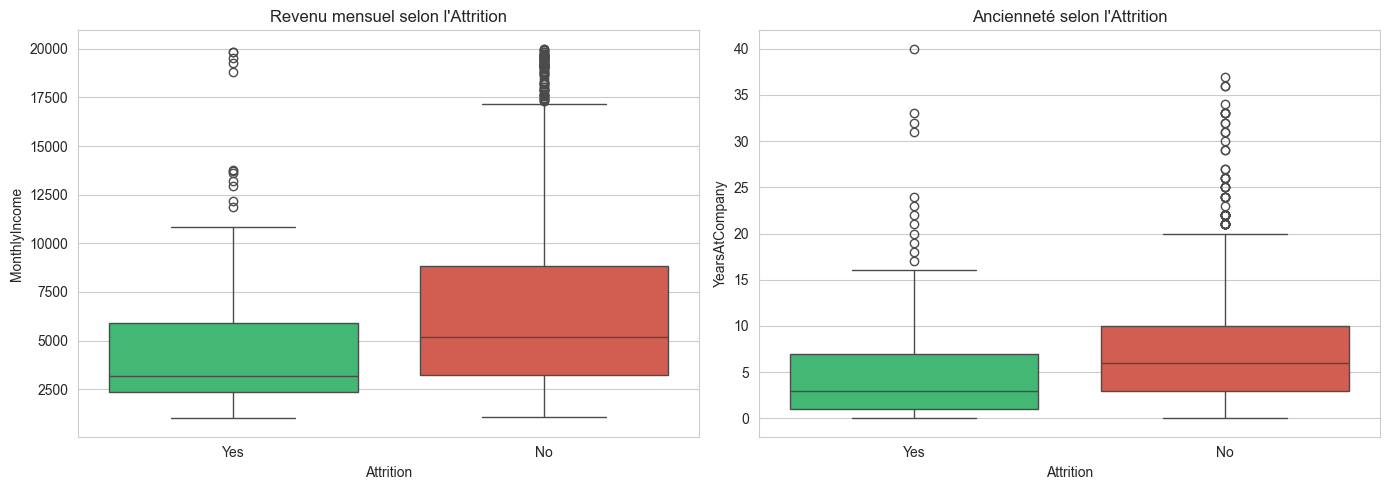

In [ ]:
# Attrition selon le revenu mensuel et l'ancienneté
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[0],
            palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Revenu mensuel selon l\'Attrition')

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Ancienneté selon l\'Attrition')

plt.tight_layout()
plt.show()

Taux d'attrition par département (%) :
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


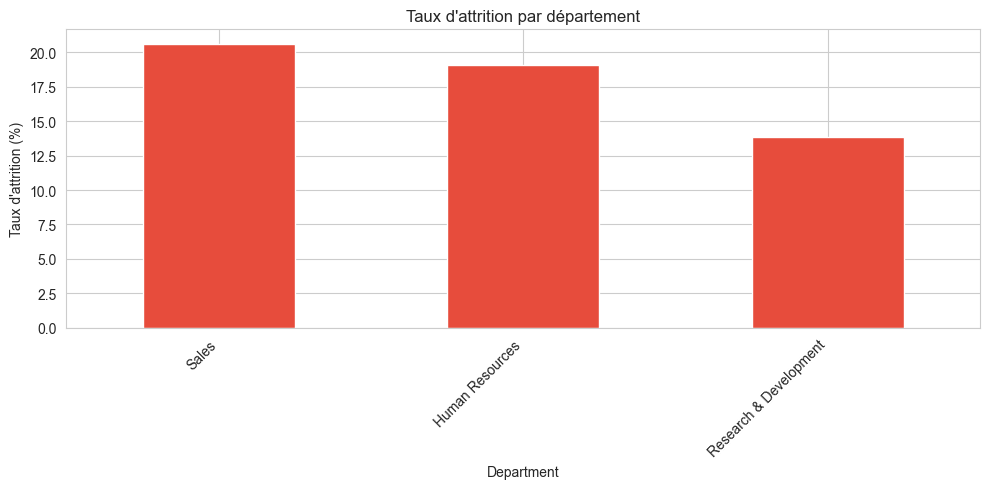

In [ ]:
# Taux d'attrition par département
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(2).sort_values(ascending=False)
print('Taux d\'attrition par département (%) :')
print(dept_attrition)

plt.figure(figsize=(10, 5))
dept_attrition.plot(kind='bar', color='#e74c3c')
plt.title('Taux d\'attrition par département')
plt.ylabel('Taux d\'attrition (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Synthèse de l'EDA

**Ce que l'on retient de cette exploration :**

- Le dataset contient **1 470 employés** et **35 variables**, sans valeur manquante.
- **3 colonnes constantes** (`EmployeeCount`, `Over18`, `StandardHours`) seront supprimées.
- La variable cible **Attrition** est **déséquilibrée** (~16% de départs) → correction par SMOTE nécessaire.
- Premiers facteurs visibles : les heures supplémentaires, un âge plus jeune, un revenu plus faible et une faible ancienneté semblent associés à un risque de départ plus élevé.

**Prochaine étape (Notebook 2)** : préparation des données (encodage, suppression des colonnes inutiles, SMOTE) puis étude comparative des modèles.